# Composite ROI Regression Model

This notebook trains a regression model to predict `composite_roi_score`.

The `composite_roi_score` is defined as the average of `AT_mean`, `D_mean`, and `E_mean`.
It represents a business-level proxy for training impact and performance perception.
Unlike classification models, regression allows finer-grained prediction values.

Given the dataset size (`n=100`), results should be interpreted as exploratory.

## Leakage Prevention Strategy

**Target:** `composite_roi_score`

To prevent target leakage, we exclude engineered aggregates used to compute the target:
- `composite_roi_score`
- `AT_mean`
- `D_mean`
- `E_mean`

We also exclude direct behavioral drivers:
- `motivation_score`
- `delta_motivation_score`
- `motivation_improved`
- `dependency_risk`
- `dependency_risk_high`
- `dependency_level`
- `self_efficacy_score`

Raw `AT*`, `D*`, and `E*` item-level variables are also excluded.

Only contextual, demographic, and AI usage variables are used.

In [1]:
# Import required libraries for data handling, modeling, plotting, file management, and serialization.
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn utilities for model training and evaluation.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate, cross_val_predict

# Define a helper function to locate the project root by searching for .env and backend directory.
def _find_project_root(start_path: str) -> str:
    """Find project root by walking up until .env and backend directory are found."""
    current = os.path.abspath(start_path)
    while True:
        env_candidate = os.path.join(current, '.env')
        backend_candidate = os.path.join(current, 'backend')
        if os.path.isfile(env_candidate) and os.path.isdir(backend_candidate):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise ValueError('Could not locate project root containing .env and backend directory.')

# Define a helper function to read a single key from .env without external dependencies.
def _read_env_value(env_file: str, key: str) -> str:
    """Read one key from .env file without external dependencies."""
    if not os.path.isfile(env_file):
        return ''
    with open(env_file, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith('#') or '=' not in raw:
                continue
            k, v = raw.split('=', 1)
            if k.strip() == key:
                return v.strip().strip('\"').strip("'")
    return ''

# Resolve project root and .env path.
project_root = _find_project_root(os.getcwd())
env_path = os.path.join(project_root, '.env')

# Resolve engineered dataset directory from environment with fallback.
engineered_data_dir = os.getenv('ENGINEERED_DATA_DIR') or _read_env_value(env_path, 'ENGINEERED_DATA_DIR') or 'backend/data/processed'
if not os.path.isabs(engineered_data_dir):
    engineered_data_dir = os.path.join(project_root, engineered_data_dir)

# Build dataset path and validate file existence before loading.
processed_path = os.path.join(engineered_data_dir, 'survey_engineered.csv')
if not os.path.exists(processed_path):
    raise FileNotFoundError(f'Engineered dataset not found at: {processed_path}')

# Load engineered dataset.
df = pd.read_csv(processed_path)

# Validate target column availability.
if 'composite_roi_score' not in df.columns:
    raise ValueError("Required target column 'composite_roi_score' not found in engineered dataset.")

# Print dataset overview and target summary statistics.
print(f'Engineered dataset loaded from: {processed_path}')
print(f'Dataset shape: {df.shape}')
print('Target summary statistics (composite_roi_score):')
print(df['composite_roi_score'].describe())

Engineered dataset loaded from: /workspaces/EvaluAI/backend/data/processed/survey_engineered.csv
Dataset shape: (100, 55)
Target summary statistics (composite_roi_score):
count    100.000000
mean       4.015000
std        0.556234
min        3.000000
25%        3.583333
50%        4.000000
75%        4.333333
max        5.583333
Name: composite_roi_score, dtype: float64


In [2]:
# Define leakage-free structural whitelist using contextual, demographic, and AI usage variables only.
demographic_features = [
    'edad',
    'antiguedad_empresa',
    'rol_tecnico'
]

ai_usage_features = [
    'frecuencia_uso_ia',
    'usa_chatgpt',
    'usa_gemini',
    'usa_copilot',
    'usa_lms_ia',
    'usa_otra_ia',
    'prefiere_humano_vs_ia',
    'nivel_integracion_ia'
]

categorical_features = [
    'genero',
    'departamento',
    'sector',
    'nivel_educativo',
    'herramienta_principal'
]

# Define required columns and validate they are present in the dataframe.
required_columns = demographic_features + ai_usage_features + categorical_features + ['composite_roi_score']
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

# Build raw feature matrix from leakage-free variables only.
X_raw = df[demographic_features + ai_usage_features + categorical_features].copy()

# Convert numeric whitelist columns to numeric format and impute missing values with median.
numeric_whitelist = demographic_features + ai_usage_features
for col in numeric_whitelist:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
X_raw[numeric_whitelist] = X_raw[numeric_whitelist].fillna(X_raw[numeric_whitelist].median())

# Fill missing categorical values and perform one-hot encoding with drop_first=True.
X_raw[categorical_features] = X_raw[categorical_features].fillna('Unknown').astype(str)
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Prepare regression target and ensure numeric type.
y = pd.to_numeric(df['composite_roi_score'], errors='coerce')
if y.isna().any():
    raise ValueError('Target composite_roi_score contains non-numeric or missing values after conversion.')

# Print feature engineering output dimensions.
print(f'Number of features: {X.shape[1]}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Number of features: 28
X shape: (100, 28)
y shape: (100,)


In [3]:
# Initialize RandomForestRegressor with fixed hyperparameters for reproducibility and stability.
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Define reproducible 5-fold cross-validation splitter.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define regression metrics for model evaluation.
scoring = {
    'r2': 'r2',
    'neg_mean_absolute_error': 'neg_mean_absolute_error',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error'
}

# Run cross-validation and keep train scores to inspect overfitting.
cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print('Cross-validation completed successfully.')

Cross-validation completed successfully.


In [4]:
# Compute means and standard deviations for each metric across folds.
r2_mean = float(np.mean(cv_results['test_r2']))
r2_std = float(np.std(cv_results['test_r2']))
mae_mean = float(-np.mean(cv_results['test_neg_mean_absolute_error']))
mae_std = float(np.std(-cv_results['test_neg_mean_absolute_error']))
rmse_mean = float(-np.mean(cv_results['test_neg_root_mean_squared_error']))
rmse_std = float(np.std(-cv_results['test_neg_root_mean_squared_error']))

# Compute train-test gap using R² to inspect potential overfitting.
train_r2_mean = float(np.mean(cv_results['train_r2']))
train_test_gap = float(train_r2_mean - r2_mean)

# Build summary table with required fields.
cv_summary_table = pd.DataFrame([
    {
        'R² (mean ± std)': f'{r2_mean:.4f} ± {r2_std:.4f}',
        'MAE (mean ± std)': f'{mae_mean:.4f} ± {mae_std:.4f}',
        'RMSE (mean ± std)': f'{rmse_mean:.4f} ± {rmse_std:.4f}',
        'Train-test gap (R²)': round(train_test_gap, 4)
    }
])

print('Cross-validation summary table:')
print(cv_summary_table.to_string(index=False))

# R² near 0 indicates weak explanatory power, and negative R² means worse than a mean predictor.
print('Comment: R² near 0 indicates weak explanatory power. Negative R² means worse than mean predictor.')

Cross-validation summary table:
 R² (mean ± std) MAE (mean ± std) RMSE (mean ± std)  Train-test gap (R²)
-0.1999 ± 0.2542  0.4573 ± 0.0267   0.5693 ± 0.0574               0.9616
Comment: R² near 0 indicates weak explanatory power. Negative R² means worse than mean predictor.


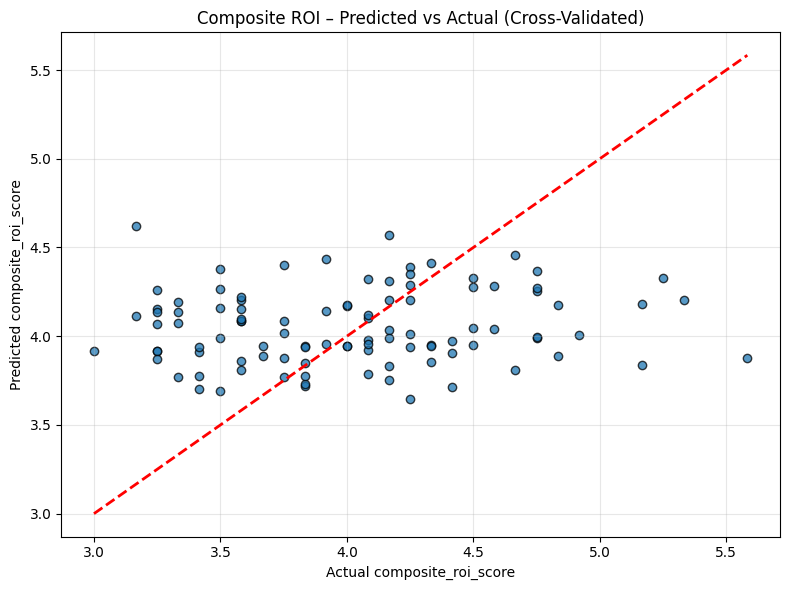

In [5]:
# Generate cross-validated predictions for unbiased predicted-vs-actual visualization.
y_pred_cv = cross_val_predict(rf_model, X, y, cv=cv, n_jobs=-1)

# Build scatter plot of actual vs predicted composite ROI values.
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_cv, alpha=0.75, edgecolor='k')

# Add diagonal line to represent perfect predictions.
diag_min = float(min(y.min(), y_pred_cv.min()))
diag_max = float(max(y.max(), y_pred_cv.max()))
plt.plot([diag_min, diag_max], [diag_min, diag_max], 'r--', linewidth=2)

# Configure plot labels and title.
plt.xlabel('Actual composite_roi_score')
plt.ylabel('Predicted composite_roi_score')
plt.title('Composite ROI – Predicted vs Actual (Cross-Validated)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 feature importances:
                     feature  importance
                        edad    0.221293
          antiguedad_empresa    0.141403
        nivel_integracion_ia    0.136983
       prefiere_humano_vs_ia    0.078070
           frecuencia_uso_ia    0.044857
       nivel_educativo_Grado    0.034502
                 usa_copilot    0.025069
herramienta_principal_Gemini    0.023726
           genero_No binario    0.023149
herramienta_principal_LMS IA    0.022799


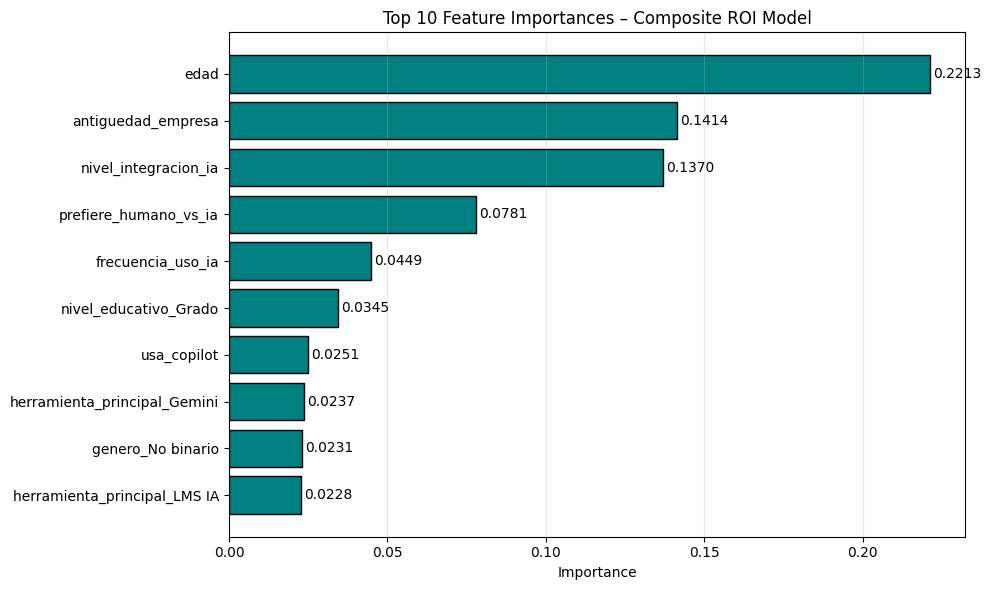

In [6]:
# Train final model on the full dataset to generate deployable artifacts.
final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X, y)

# Extract and sort feature importances in descending order.
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Display top 10 most important features.
top_10 = feature_importance_df.head(10).copy()
print('Top 10 feature importances:')
print(top_10.to_string(index=False))

# Plot top 10 feature importances as a horizontal bar chart.
plot_top = top_10.sort_values('importance', ascending=True)
plt.figure(figsize=(10, 6))
bars = plt.barh(plot_top['feature'], plot_top['importance'], color='teal', edgecolor='black')
for bar, value in zip(bars, plot_top['importance']):
    plt.text(value + 0.001, bar.get_y() + bar.get_height() / 2, f'{value:.4f}', va='center')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances – Composite ROI Model')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Resolve model output directory from environment/.env with fallback to backend/ml/models.
model_dir = os.getenv('MODEL_PATH') or _read_env_value(env_path, 'MODEL_PATH') or 'backend/ml/models'
if not os.path.isabs(model_dir):
    model_dir = os.path.join(project_root, model_dir)

# Create model output directory if it does not exist.
os.makedirs(model_dir, exist_ok=True)

# Save the trained model artifact.
model_path = os.path.join(model_dir, 'composite_roi_model.pkl')
joblib.dump(final_model, model_path)

# Build cross-validation metric dictionary using positive error metrics.
cv_metrics = {
    'r2': r2_mean,
    'mae': mae_mean,
    'rmse': rmse_mean
}

# Build metadata payload with required model information and traceability fields.
metadata = {
    'model_type': 'RandomForestRegressor',
    'parameters': {
        'n_estimators': 300,
        'max_depth': 8,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'random_state': 42
    },
    'n_features': int(X.shape[1]),
    'feature_names': X.columns.tolist(),
    'target': 'composite_roi_score',
    'cross_validation_metrics': cv_metrics,
    'note': 'Leakage-free regression model',
    'timestamp': pd.Timestamp.utcnow().isoformat()
}

# Save metadata as JSON next to the model artifact.
metadata_path = os.path.join(model_dir, 'composite_roi_model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

# Print output paths for reproducibility and traceability.
print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {metadata_path}')

Model saved to: /workspaces/EvaluAI/backend/ml/models/composite_roi_model.pkl
Metadata saved to: /workspaces/EvaluAI/backend/ml/models/composite_roi_model_metadata.json


### Interpretation of Metrics

- **R²**: Proportion of variance explained by the model.
- **MAE**: Average absolute prediction error.
- **RMSE**: Penalizes larger errors more strongly.

### Limitations

- With 100 samples, variance is high.
- ROI perception may depend more on behavioral constructs excluded here.

### Business Meaning

- If R² > 0.2, there is meaningful structural signal.
- If R² ≈ 0, ROI perception is likely driven by attitudinal factors.
- Feature importance highlights structural drivers of perceived ROI.

This model predicts perceived ROI from contextual variables,
not from the items that define ROI itself.